In [1]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import haversine_distances
from scipy.stats import shapiro

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.precision', 2)
warnings.filterwarnings('ignore')

In [3]:
raw = "C:\\Users\\Taavi\\Desktop\\BPhil\\Raw data\\"
clean = "C:\\Users\\Taavi\\Desktop\\BPhil\\Clean data\\"

In [4]:
parcels = pd.read_csv(clean + 'clean_parcels.csv')

adjustments = pd.read_csv(clean + 'parcels_with_adjustments.csv')
adj_cols = [f'adjustment_{R}' for R in np.arange(50, 800, 50)]
parcels = parcels.merge(adjustments[['parcelID'] + adj_cols], on = 'parcelID', how = 'left')

num_parcels = pd.read_csv(clean + 'parcels_with_num_parcels.csv')
parcels = parcels.merge(num_parcels, on = 'parcelID', how = 'left')

In [5]:
viols = pd.read_csv(clean + 'clean_viols.csv')
violsOld = pd.read_csv(clean + 'clean_viols_old.csv')

In [6]:
viols['date'] = pd.to_datetime(viols['date'])
violsOld['date'] = pd.to_datetime(violsOld['date'])

### Concat viols

In [7]:
viols = pd.concat([viols, violsOld], axis = 0).sort_values(by = 'date')

In [8]:
viols.shape[0]

376093

### Filter for post-2020

In [9]:
viols = viols.loc[viols['date'].dt.year >= 2020]

In [10]:
viols.shape[0]

361841

### Filter viols for Dylan Cork's list of relevant codes

In [11]:
viols = viols.loc[(viols['code'].str.contains('IPMC')) | (viols['code'].str.contains('CITY')) | (viols['code'].str.contains('City'))]

In [12]:
viols.shape[0]

274483

### Drop all duplicates - because we just want to count each violation once for the aggregate timeframe

In [13]:
viols = viols.drop_duplicates(subset = ['violID', 'parcelID'])

In [14]:
viols.shape[0]

69602

In [15]:
viols.to_csv(clean + 'viols_ready_to_measure.csv', index = False)

In [16]:
viols = pd.read_csv(clean + 'viols_ready_to_measure.csv')

### Comparing viols between oakland and the hill district

In [17]:
viols

,violID,parcelID,date,code,outcome,lat,lng
0,O-1613049,0046G00202000000,2020-01-02,2003 IPMC 108.1.1 Unsafe Structure :: 2003 IPM...,Violations Found,40.47,-80.00
1,O-1619687,0050M00016000A00,2020-01-02,2003 IPMC 108.1.1 Unsafe Structure,Violations Found,40.47,-79.94
2,O-1607759,0003E00250000000,2020-01-02,2003 IPMC 302.3 Sidewalks and driveways,Violations Found,40.43,-80.00
3,O-1618689,0077J00074000000,2020-01-02,2003 IPMC 108.1.3 Structure Unfit for Human Oc...,Violations Found,40.47,-80.01
4,O-1612005,0125C00069000000,2020-01-02,2003 IPMC 108.1.1 Unsafe Structure :: 2003 IPM...,Violations Found,40.46,-79.91
...,...,...,...,...,...,...,...
69597,CF-PLI-2025-040441,0003M00001000000,2025-08-14,2015 IPMC 308.1,VIOLATION FOUND,40.43,-79.98
69598,CF-PLI-2025-040445,0029N00157000000,2025-08-14,2015 IPMC 301.3,SEND TO CLEAN & LIEN,40.43,-79.96
69599,CF-PLI-2025-040957,0025K00210000000,2025-08-14,2015 IPMC 302.4,VIOLATION FOUND,40.46,-79.98
69600,CF-PLI-2025-035489,0062A00205000000,2025-08-14,2015 IPMC 302.4,VIOLATION FOUND,40.40,-80.03


In [18]:
parcels = pd.read_csv(clean + 'clean_parcels.csv')

In [19]:
viols = viols.merge(right = parcels[['parcelID', 'nbrhd']], on = 'parcelID', how = 'left')

In [20]:
parcels['nbrhd'].sort_values().unique()

array(['Allegheny Center', 'Allegheny West', 'Allentown', 'Arlington',
       'Arlington Heights', 'Banksville', 'Bedford Dwellings',
       'Beechview', 'Beltzhoover', 'Bloomfield', 'Bluff', 'Bon Air',
       'Brighton Heights', 'Brookline', 'California-Kirkbride', 'Carrick',
       'Central Business District', 'Central Lawrenceville',
       'Central Northside', 'Central Oakland', 'Chartiers City',
       'Chateau', 'Crafton Heights', 'Crawford-Roberts',
       'Duquesne Heights', 'East Allegheny', 'East Carnegie',
       'East Hills', 'East Liberty', 'Elliott', 'Esplen', 'Fairywood',
       'Fineview', 'Friendship', 'Garfield', 'Glen Hazel', 'Greenfield',
       'Hays', 'Hazelwood', 'Highland Park', 'Homewood North',
       'Homewood South', 'Homewood West', 'Knoxville', 'Larimer',
       'Lincoln Place', 'Lincoln-Lemington-Belmar', 'Lower Lawrenceville',
       'Manchester', 'Marshall-Shadeland', 'Middle Hill', 'Morningside',
       'Mount Washington', 'Mt. Oliver', 'New Homestead'

In [21]:
oakland = ['Central Oakland', 'South Oakland']
hill = ['Middle Hill', 'Upper Hill', 'Crawford-Roberts', 'Bedford Dwellings', 'Terrace Village']
southside = ['South Side Flats', 'South Side Slopes']
south = ['Knoxville', 'Allentown', 'Beltzhoover', 'Mt. Oliver', 'Mount Washington']

In [22]:
viols['area'] = np.where(viols['nbrhd'].isin(oakland), 'oakland', np.where(viols['nbrhd'].isin(hill), 'hill district', np.where(viols['nbrhd'].isin(southside), 'southside', np.where(viols['nbrhd'].isin(south), 'south', 'other'))))

In [23]:
viols['class'] = np.where(viols['code'].str.contains('IPMC'), 'IPMC', 'city')

In [24]:
viols.groupby('area')['class'].value_counts(normalize = True)

area           class
hill district  IPMC     0.91
               city     0.09
oakland        city     0.66
               IPMC     0.34
other          IPMC     0.76
               city     0.24
south          IPMC     0.81
               city     0.19
southside      IPMC     0.59
               city     0.41
Name: proportion, dtype: float64

### Count violations

In [17]:
# convert geocodes to radians
parcels_coords = np.radians(parcels[['lat', 'lng']].values)
viols_coords = np.radians(viols[['lat', 'lng']].values)

In [18]:
# earth's radius in meters
earth_radius = 6_378_137 # chat-gpt said 6,371,000 but University of Southern Florida disagrees. I'm using USF

viol_tree = BallTree(viols_coords, metric = 'haversine')

In [19]:
# distance bins
distances = np.arange(50, 800, 50)
distances_radians = distances / earth_radius

In [20]:
# count violations in each distance bin
for d_m, d_r in zip(distances, distances_radians):
    indices_within_radius = viol_tree.query_radius(parcels_coords, r = d_r)
    counts = [len(idxs) for idxs in indices_within_radius]
    parcels[f'viols_count_{d_m}'] = counts

In [21]:
row_one = parcels.iloc[10_000:10_002].copy()

### Annuli adjustment

In [22]:
for i, r in enumerate(distances[::-1]):
    if r != distances[0]:
        parcels[f'viols_count_{r}'] -= parcels[f'viols_count_{distances[::-1][i + 1]}']

In [23]:
row_two = parcels.iloc[10_000:10_002].copy()

In [24]:
parcels.to_csv(clean + 'viols_counts.csv', index = False)

In [25]:
parcels = pd.read_csv(clean + 'viols_counts.csv')

### Adjusting for measurement area outside of the city boundary

In [26]:
for r in distances:
    parcels[f'viols_count_{r}'] = parcels[f'viols_count_{r}'] / parcels[f'adjustment_{r}']

### Divide by num_parcels to get BPU (blight-per-unit)

In [27]:
# for r in distances:
#     parcels[f'viols_count_{r}'] = parcels[f'viols_count_{r}'] / parcels[f'parcels_count_{r}']

### Distance decay and sum across bins for score

In [28]:
weights = [(len(distances) - i) / len(distances) for i, r in enumerate(distances)]

In [29]:
parcels['viols_score'] = (parcels.iloc[:, -len(distances):] * weights).sum(axis = 1)
parcels.loc[parcels['viols_score'] == -np.inf, 'viols_score'] = 0

In [30]:
row_three = pd.concat([row_two.iloc[:, :-len(distances)], row_two.iloc[:, -len(distances):] * weights], axis = 1)

### Show all rows together

In [31]:
pd.concat([row_one, row_two, row_three], axis = 0).iloc[::2, list(np.arange(0, 4, 1)) + list(np.arange(34, row_one.shape[1], 1))].assign(process = ['raw_count', 'annuli_adjustment', 'distance_decay']).set_index('process')

,parcelID,lat,lng,nbrhd,parcels_count_650,parcels_count_700,parcels_count_750,viols_count_50,viols_count_100,viols_count_150,viols_count_200,viols_count_250,viols_count_300,viols_count_350,viols_count_400,viols_count_450,viols_count_500,viols_count_550,viols_count_600,viols_count_650,viols_count_700,viols_count_750
process,,,,,,,,,,,,,,,,,,,,,,
raw_count,0008H00093000000,40.45,-80.0,North Shore,135,169,173,0.0,0.0,0.0,1.0,3.00,7.00,43.0,62.00,96.00,165.0,222.0,295.00,355.0,450.00,542.00
annuli_adjustment,0008H00093000000,40.45,-80.0,North Shore,135,169,173,0.0,0.0,0.0,1.0,2.00,4.00,36.0,19.00,34.00,69.0,57.0,73.00,60.0,95.00,92.00
distance_decay,0008H00093000000,40.45,-80.0,North Shore,135,169,173,0.0,0.0,0.0,0.8,1.47,2.67,21.6,10.13,15.87,27.6,19.0,19.47,12.0,12.67,6.13


$$
\text{Exposure}_k = \sum_{i=0}^{n-1} \frac{n - i}{n} x_{k,i}
$$

### Transformations

In [32]:
parcels['viols_log'] = np.log1p(parcels['viols_score'])
parcels['viols_sqrt'] = np.sqrt(parcels['viols_score'])

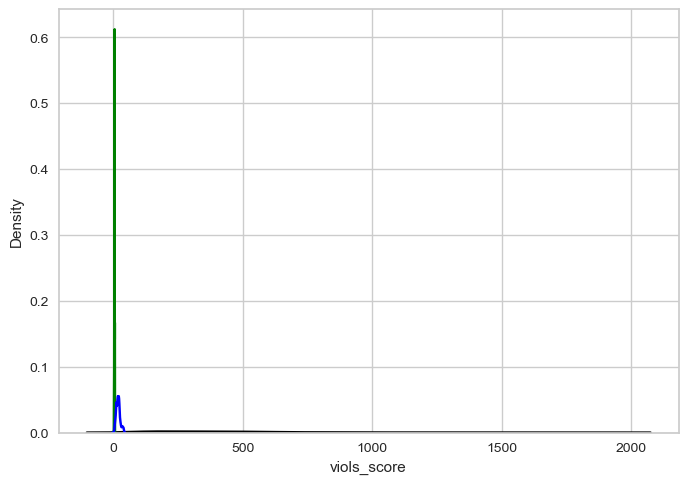

In [34]:
sns.kdeplot(parcels['viols_score'], color = 'black')
sns.kdeplot(parcels['viols_log'], color = 'green')
sns.kdeplot(parcels['viols_sqrt'], color = 'blue')
plt.show()

In [35]:
skew(parcels['viols_score']), skew(parcels['viols_log']), skew(parcels['viols_sqrt'])

(np.float64(1.554957379535427),
 np.float64(-0.6971092181177327),
 np.float64(0.5943884070266413))

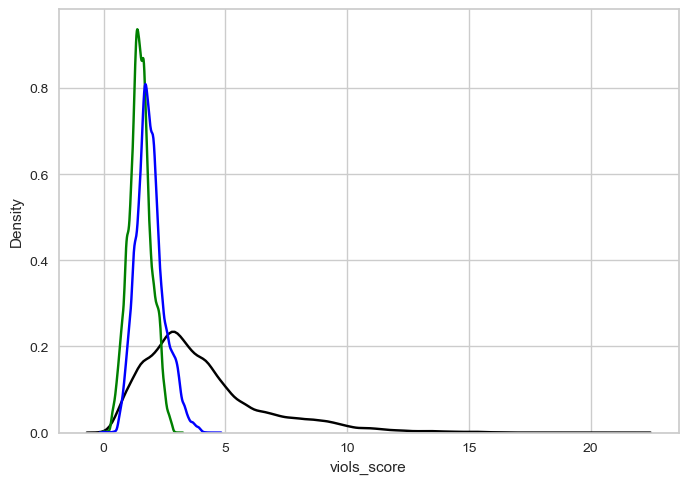

In [92]:
sns.kdeplot(parcels['viols_score'], color = 'black')
sns.kdeplot(parcels['viols_log'], color = 'green')
sns.kdeplot(parcels['viols_sqrt'], color = 'blue')
plt.show()

In [94]:
skew(parcels['viols_score']), skew(parcels['viols_log']), skew(parcels['viols_sqrt'])

(np.float64(1.402132648781495),
 np.float64(0.1025395867307099),
 np.float64(0.5445059773907847))

In [37]:
pd.concat([parcels.iloc[:, :5], parcels.iloc[:, -3:]], axis= 1)

,parcelID,lat,lng,nbrhd,tract,viols_score,viols_log,viols_sqrt
0,0001A00100000000,40.44,-80.01,Central Business District,20100,25.67,3.28,5.07
1,0001B00010000000,40.44,-80.01,Central Business District,20100,65.67,4.20,8.10
2,0001B00024000000,40.44,-80.01,Central Business District,20100,38.07,3.67,6.17
3,0001B00026000000,40.44,-80.01,Central Business District,20100,40.20,3.72,6.34
4,0001B00050000000,40.44,-80.01,Central Business District,20100,46.93,3.87,6.85
...,...,...,...,...,...,...,...,...
144026,8000T04522000000,40.40,-80.00,Brookline,320600,167.20,5.13,12.93
144027,8000T04662000000,40.39,-80.00,Brookline,320600,164.67,5.11,12.83
144028,8000T04810000000,40.41,-80.03,Banksville,202300,68.40,4.24,8.27
144029,8000T04973000000,40.45,-80.07,Windgap,563000,286.40,5.66,16.92


In [38]:
parcels = pd.concat([parcels.iloc[:, :5], parcels.iloc[:, -3:]], axis= 1)

In [39]:
parcels.to_csv(clean + 'viols_transformations.csv', index = False)

In [33]:
parcels = pd.read_csv(clean + 'viols_transformations.csv')

In [1]:
# fig = px.scatter_mapbox(parcels, lat = 'lat', lon = 'lng', color = 'viols_score', color_continuous_scale = 'viridis', zoom = 10, hover_data = ['nbrhd'])
# fig.update_layout(mapbox_style = 'open-street-map')
# fig.show()

In [2]:
# fig = px.scatter_mapbox(parcels, lat = 'lat', lon = 'lng', color = 'viols_log', color_continuous_scale = 'viridis', zoom = 10, hover_data = ['nbrhd'])
# fig.update_layout(mapbox_style = 'open-street-map')
# fig.show()

In [3]:
# fig = px.scatter_mapbox(parcels, lat = 'lat', lon = 'lng', color = 'viols_sqrt', color_continuous_scale = 'viridis', zoom = 10, hover_data = ['nbrhd'])
# fig.update_layout(mapbox_style = 'open-street-map')
# fig.show()